#  Modelado

### Evaluamos 3 modelos con validación cruzada (5-fold) usando RMSE.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

In [15]:
train = pd.read_csv(r"../data/train_clean.csv")
test = pd.read_csv(r"../data/test_clean.csv")
train_sin_outl = pd.read_csv(r"../data/train_clean_sin_outl.csv")

In [16]:
train.head()

,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,antiguedad,producto_barato_caro,visibilidad_por_precio,clasificacion_visibilidad,Item_Fat_Content_Regular,Item_Type_Breads,...,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,0.016047,249.8092,1999,3735.1380,27,1,0.000064,0,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.019278,48.2692,2009,443.4228,17,0,0.000399,0,True,False,...,False,False,False,True,False,False,True,False,True,False
2,0.016760,141.6180,1999,2097.2700,27,0,0.000118,0,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.000000,182.0950,1998,732.3800,28,1,0.000000,0,True,False,...,False,False,False,False,False,False,True,False,False,False
4,0.000000,53.8614,1987,994.7052,39,0,0.000000,0,False,False,...,False,False,False,False,False,False,True,True,False,False


## Separamos en X y Y 

In [17]:
X = train.drop("Item_Outlet_Sales", axis=1)
y = train["Item_Outlet_Sales"]

X_test = test.reindex(columns=X.columns, fill_value=0)

## División del Dataset en Entrenamiento y Validación

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42     
)

print(f"Train: {X_train.shape}")
print(f"Validación: {X_val.shape}")

Train: (6818, 28)
Validación: (1705, 28)


## 1. MODELO REGRESION LINEAL

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# PREDICCION
y_pred_lr = lr.predict(X_val)

# METRICAS
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
mae_lr = mean_absolute_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)

print("Regresión Lineal")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE:  {mae_lr:.2f}")
print(f"R2:   {r2_lr:.4f}")

Regresión Lineal
RMSE: 1068.28
MAE:  793.10
R2:   0.5801


## 2. MODELO RANDOM FOREST

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,   
    random_state=42,
    n_jobs=-1           
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf = mean_absolute_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE:  {mae_rf:.2f}")
print(f"R2:   {r2_rf:.4f}")

Random Forest
RMSE: 1103.63
MAE:  768.62
R2:   0.5519


In [21]:
y_pred_rf_train = rf.predict(X_train)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
r2_rf_train = r2_score(y_train, y_pred_rf_train)

print("=== Random Forest - Training vs Validación ===")
print(f"RMSE Train: {rmse_rf_train:.2f}  |  RMSE Val: {rmse_rf:.2f}")
print(f"R2 Train:   {r2_rf_train:.4f}    |  R2 Val:   {r2_rf:.4f}")

=== Random Forest - Training vs Validación ===
RMSE Train: 434.12  |  RMSE Val: 1103.63
R2 Train:   0.9363    |  R2 Val:   0.5519


## 3. MODELO XGBOOST

In [22]:
xgb = XGBRegressor(        # VALORES AJUSTADOS (ORIGINAL)
    n_estimators=100,      # 300
    learning_rate=0.05,    # 0.08
    max_depth=4,           # 5
    subsample=0.8,         # usa 80% de los datos por árbol (evita overfitting)
    colsample_bytree=0.8,  # usa 80% de las columnas por árbol (evita overfitting)
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)
y_pred_xgb_train = xgb.predict(X_train)

rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))

print("XGBOOST")
print(f"RMSE Train: {rmse_xgb_train:.2f}  |  RMSE Val: {rmse_xgb:.2f}")
print(f"R2 Train:   {r2_xgb_train:.4f}   |  R2 Val:   {r2_xgb:.4f}")
print(f"                     |  MAE Val:  {mae_xgb:.2f}")

XGBOOST
RMSE Train: 1047.98  |  RMSE Val: 1027.80
R2 Train:   0.6287   |  R2 Val:   0.6113
                     |  MAE Val:  728.90


## Validación del modelo con diferentes particiones

In [23]:
cortes = [1, 7, 42, 99, 123]

for cortes in cortes:

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=cortes
    )

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    r2 = r2_score(y_val, pred)

    print(f"Cortes {cortes}: R2 = {r2:.4f}")

Cortes 1: R2 = 0.5908
Cortes 7: R2 = 0.5809
Cortes 42: R2 = 0.6113
Cortes 99: R2 = 0.6100
Cortes 123: R2 = 0.5965


## Validación cruzada del modelo

In [24]:

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("PROMEDIO:", round(scores.mean(),4))
print("DESVIACION:", round(scores.std(),4))

[0.60413542 0.58378062 0.57588567 0.60032709 0.60567506]
PROMEDIO: 0.594
DESVIACION: 0.0119


> **OBSERVACIONES:**
> - Se eligió el modelo **XGBoost** debido a que fue el que obtuvo mejores resultados en comparación con **Regresión Lineal** y **Random Forest**, donde se observaron indicios de overfitting.  
> - Además, se validó el desempeño del modelo utilizando distintos cortes de datos (diferentes `random_state`) y mediante **validación cruzada**, lo que permitió evaluar su estabilidad y capacidad de generalización.

## IMPORTANCIA DE FEATURES

TOP 10 FEATURE MAS IMPORTANTES
producto_barato_caro             0.532209
Outlet_Type_Supermarket Type1    0.086993
Outlet_Type_Supermarket Type3    0.072404
Item_MRP                         0.064291
Outlet_Location_Type_Tier 3      0.060652
antiguedad                       0.040922
Outlet_Establishment_Year        0.035225
Outlet_Type_Supermarket Type2    0.014771
visibilidad_por_precio           0.009755
Item_Type_Hard Drinks            0.007923
dtype: float32


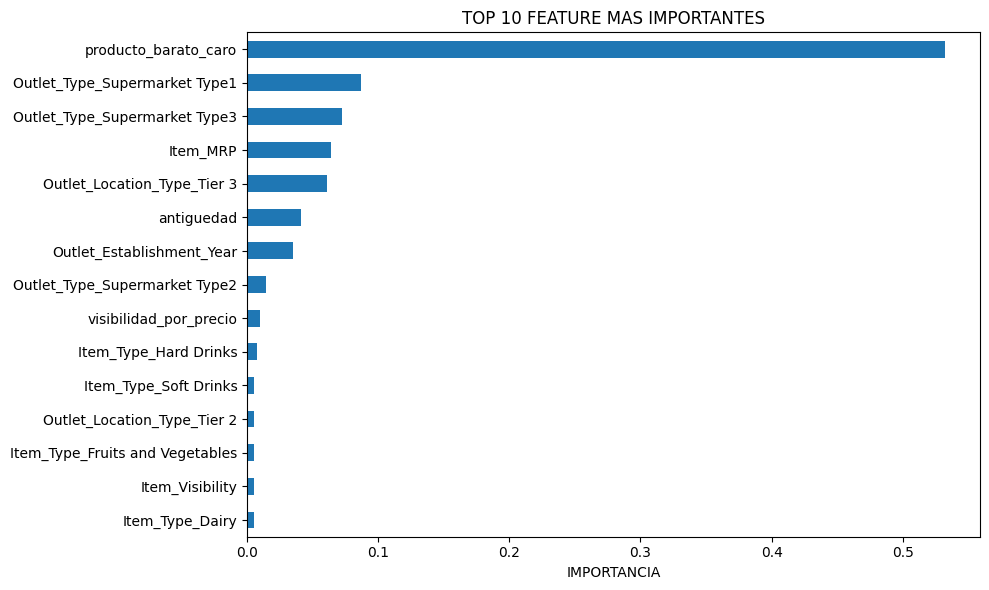

In [25]:
importancias = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("TOP 10 FEATURE MAS IMPORTANTES")
print(importancias.head(10))

# Gráfico
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("TOP 10 FEATURE MAS IMPORTANTES")
plt.xlabel("IMPORTANCIA")
plt.tight_layout()
plt.savefig("../imagenes/top_feature.png", dpi=300, bbox_inches="tight")
plt.show()

## MUESTRA SIN OUTLIER

In [26]:
X_sin_autl = train_sin_outl.drop("Item_Outlet_Sales", axis=1)
y_sin_autl = train_sin_outl["Item_Outlet_Sales"]

In [27]:
X_train_sin_autl, X_val_sin_autl, y_train_sin_autl, y_val_sin_autl = train_test_split(
    X_sin_autl, y_sin_autl,
    test_size=0.2,      
    random_state=42     
)

print(f"Train: {X_train_sin_autl.shape}")
print(f"Validación: {X_val_sin_autl.shape}")

Train: (6602, 28)
Validación: (1651, 28)


In [28]:
xgb_sin_autl = XGBRegressor(        # VALORES AJUSTADOS (ORIGINAL)
    n_estimators=100,      # 300
    learning_rate=0.05,    # 0.08
    max_depth=4,           # 5
    subsample=0.8,         # usa 80% de los datos por árbol (evita overfitting)
    colsample_bytree=0.8,  # usa 80% de las columnas por árbol (evita overfitting)
    random_state=42,
    n_jobs=-1
)

xgb_sin_autl.fit(X_train_sin_autl, y_train_sin_autl)

y_pred_xgb_sin_autl = xgb.predict(X_val_sin_autl)
y_pred_xgb_train_sin_autl = xgb.predict(X_train_sin_autl)

rmse_xgb_sin_autl = np.sqrt(mean_squared_error(y_val_sin_autl, y_pred_xgb_sin_autl))
mae_xgb_sin_autl = mean_absolute_error(y_val_sin_autl, y_pred_xgb_sin_autl)
r2_xgb_sin_autl = r2_score(y_val_sin_autl, y_pred_xgb_sin_autl)
r2_xgb_train_sin_autl = r2_score(y_train_sin_autl, y_pred_xgb_train_sin_autl)
rmse_xgb_train_sin_autl = np.sqrt(mean_squared_error(y_train_sin_autl, y_pred_xgb_train_sin_autl))

print("XGBOOST SIN OUTLIER")
print(f"RMSE Train: {rmse_xgb_train_sin_autl:.2f}  |  RMSE Val: {rmse_xgb_sin_autl:.2f}")
print(f"R2 Train:   {r2_xgb_train_sin_autl:.4f}  |  R2 Val:   {r2_xgb_sin_autl:.4f}")
print(f"                    |  MAE Val:  {mae_xgb_sin_autl:.2f}")



XGBOOST SIN OUTLIER
RMSE Train: 939.20  |  RMSE Val: 907.97
R2 Train:   0.5833  |  R2 Val:   0.6031
                    |  MAE Val:  662.62


In [29]:
print("XGBOOST CON OUTLIER")
print(f"RMSE Train: {rmse_xgb_train:.2f}  |  RMSE Val: {rmse_xgb:.2f}")
print(f"R2 Train:   {r2_xgb_train:.4f}   |  R2 Val:   {r2_xgb:.4f}")
print(f"                     |  MAE Val:  {mae_xgb:.2f}")

XGBOOST CON OUTLIER
RMSE Train: 1047.98  |  RMSE Val: 1027.80
R2 Train:   0.6287   |  R2 Val:   0.6113
                     |  MAE Val:  728.90


## Gráfico predictivo ambas muestras

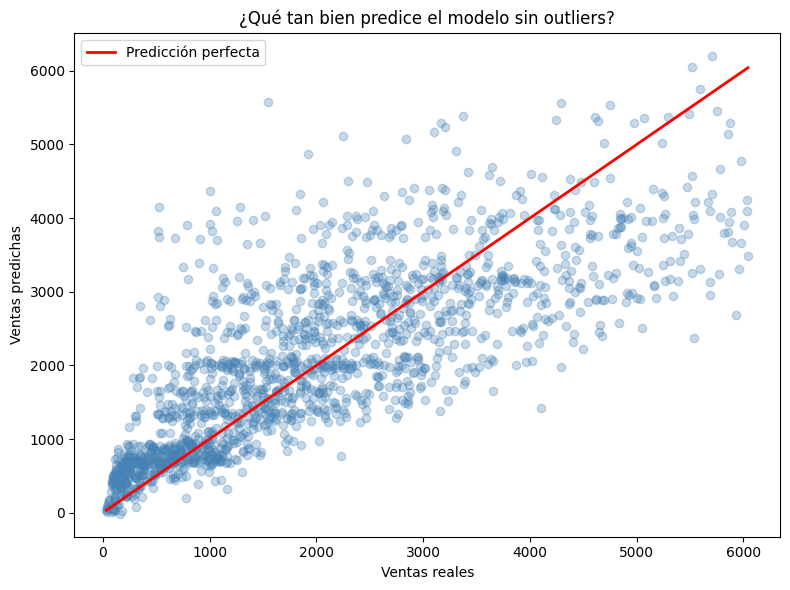

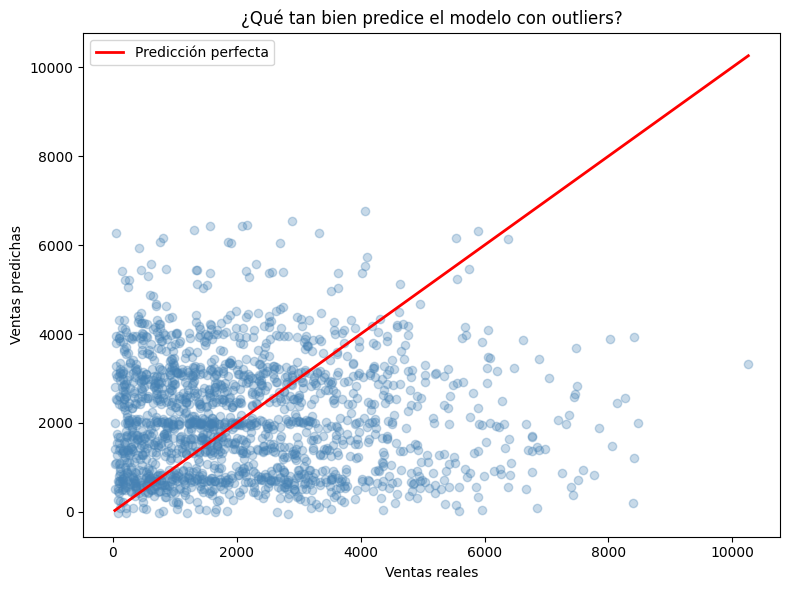

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val_sin_autl, y_pred_xgb_sin_autl, alpha=0.3, color="steelblue")
plt.plot(
    [y_val_sin_autl.min(), y_val_sin_autl.max()],
    [y_val_sin_autl.min(), y_val_sin_autl.max()],
    color="red", linewidth=2, label="Predicción perfecta"
)
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("¿Qué tan bien predice el modelo sin outliers?")
plt.legend()
plt.tight_layout()

plt.savefig("../imagenes/linea_modelo.png", dpi=300, bbox_inches="tight")

plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_xgb, alpha=0.3, color="steelblue")
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red", linewidth=2, label="Predicción perfecta"
)
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("¿Qué tan bien predice el modelo con outliers?")
plt.legend()
plt.tight_layout()
plt.show()


> **OBSERVACIONES:**
> - Se observó que el modelo presenta mejor rendimiento **sin outliers**, ya que aunque con outliers el R² es ligeramente mayor, las métricas de error (RMSE y MAE) son más bajas en el modelo sin outliers.
> - Por este motivo, se concluye que el modelo sin outliers generaliza mejor y comete menos error en sus predicciones, siendo la opción más adecuada.